### Derivative
The derivative $f'(x)$ of a function $f(x)$ represents the **rate of change of the function with respect to its input variable**. In other words, it gives the **speed** with which $f(x)$ changes compared to the input variable $x$.

#### Formula
To measure that rate of change we must check how much $f(x)$ would have changed if $x$ has moved with a **microscopic** step $\Delta$ (*delta*).
$$ f'(x) = \lim_{\Delta->0} \frac{f(x+\Delta) - f(x)}{ \Delta } $$

Let's write a Python function that calculates the first derivative of a function.

In [55]:
from collections.abc import Callable

In [56]:
def calculate_derivative_at_point(f: Callable, x: float, delta: float = 1e-7):
    """
    Calculates a numerical approximation to the derivative of the specified function
    at the given point x.

    Args:
        f (Callable): The function to calculate the derivative of
        x (float): The point at which to calculate the derivative
        delta (float, optional): The step size for the numerical approximation. Defaults to 1e-7.

    Returns:
        float: The numerical approximation to the derivative of the function at the given point x
    """
    return (f(x + delta) - f(x)) / delta

### Derivative and Slope at a Point
We'll warm up by visualizing how the derivative of a function relates to the slope of the function at a given point.

In [57]:
import numpy as np
import matplotlib.pyplot as plt

In [58]:
def plot_derivative(func: Callable, 
                    derivative_func: Callable = None, 
                    min_x: int = -10, 
                    max_x: int = 10):
    """
    Plots the function and its derivative. 
    The `derivative` parameter is optional and can be provided as a separate function.
    If it's not provided, the derivative will be calculated automatically

    Args:
        func (Callable): The function to plot
        derivative_func (Callable, optional): The derivative of the function to plot. Defaults to None.
        min_x (int, optional): The minimum x value to plot. Defaults to -10.
        max_x (int, optional): The maximum x value to plot. Defaults to 10.
    """
    # We're using vectorized functions to make our code simpler: this only hides the for-loop,
    # it doesn't provide any performance gain
    vectorized_function = np.vectorize(func)
    
    x = np.linspace(min_x, max_x, 100)
    y = vectorized_function(x)
    
    dy = []
    # CASE 1: We don't have a derivative function, so we calculate it automatically
    if derivative_func is None:
        dy = np.vectorize(calculate_derivative_at_point)(func, x)
    # CASE 1: We have a derivative function, explicitly provided
    else:
        dy = np.vectorize(derivative_func)(x)

    plt.plot(x, y, label = "f(x)")
    plt.plot(x, dy, label = "f'(x)")
    plt.xlim(min_x, max_x)
    plt.legend()
    plt.show()

Let's now test with out favourite function: $y = x^2$ whose derivative is $y' = 2x$. If we've worked correctly, both of the following plots should be the same.

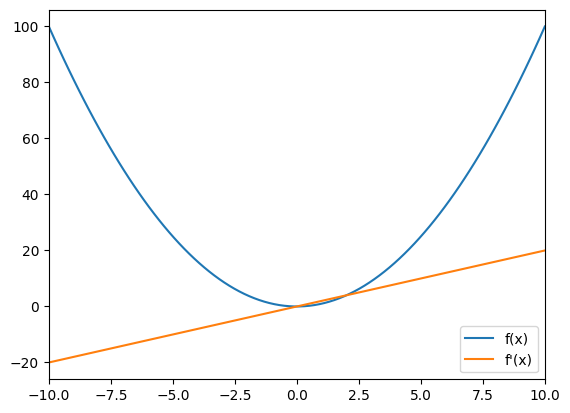

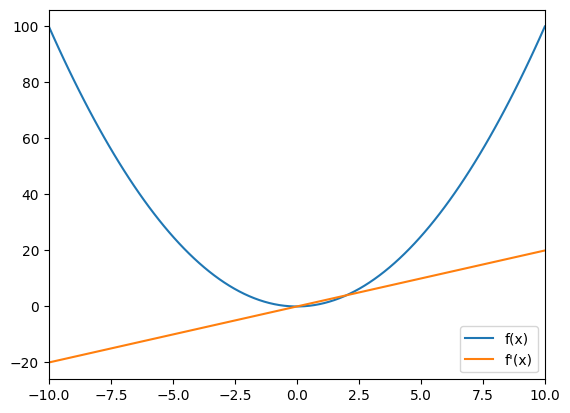

In [59]:
plot_derivative(lambda x: x ** 2, lambda x: 2 * x) # The derivative is calculated by hand
plot_derivative(lambda x: x ** 2) # The derivative is not pre-calculated, should be calculated inside the function

Let's try one more: $y = \sin(x)$, $y'= \cos(x)$.

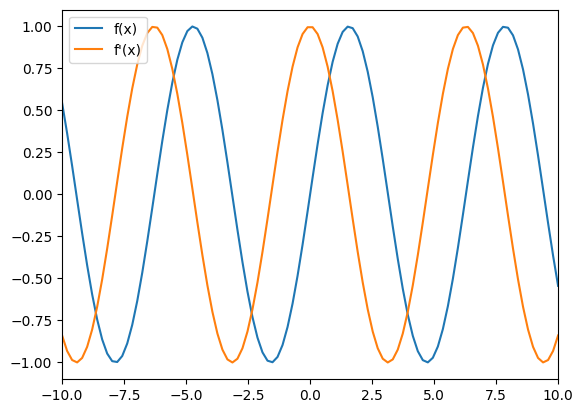

In [60]:
plot_derivative(np.sin)

These plots may look nice but they don't reflect the idea of **slope at a point** very well. Now that we're sure our functions are working, let's actually calculate the derivative at **one point** and see that it is, indeed, equal to the slope of the function at that point.

#### How to plot the tangent line?
We need to find the line equation first. 

We're given the derivative, which is equal to the slope of the line. In the line equation $y = ax + b$, the slope is $a$. We now have to find $b$. We're given a point $P(x_P; y_P)$ through which the line passes. Substitute $x_P$ and $y_P$:
$$ y_P = ax_P + b $$

$$ b = y_P - ax_P $$

Now that we have $a$ and $b$, we can plot the line given by $y = ax + b$. The parameter $b$ is sometimes called **"y-intercept"** (or "intercept").

Now we can copy the code from the previous function. This time, however, we won't plot the entire range, only one value of the derivative. We'll also show the point where we're calculating.

In [61]:
def plot_tangent_line_at_point(func: Callable, 
                      x_point: float, 
                      derivative: Callable = None,
                      min_x: int = -10, 
                      max_x: int = 10):
    """
    Plots the function in the range [x_min; x_max]. Computes the tangent line to the function
    at the given point and also plots it.

    Args:
        func (Callable): The function to plot
        point (float): The point at which to calculate the tangent line
        derivative (Callable, optional): The derivative of the function. Defaults to None.
        min_x (int, optional): The minimum x value to plot. Defaults to -10.
        max_x (int, optional): The maximum x value to plot. Defaults to 10.
    """
    vectorized_function = np.vectorize(func)
    
    x = np.linspace(min_x, max_x, 1000)
    y = vectorized_function(x)
    
    slope_a = 0 # Slope of the tangent line
    if derivative is None:
        slope_a = calculate_derivative_at_point(func, x_point)
    else:
        slope_a = derivative(x_point)
    
    intercept_b = func(x_point) - slope_a * x_point
    tangent_line_x = np.linspace(x_point - 2, x_point + 2, 10)
    tangent_line_y = slope_a * tangent_line_x + intercept_b
    plt.plot(x, y, label = "f(x)")
    plt.plot(tangent_line_x, tangent_line_y, label = f"f'(x) @ x={x_point}")
    plt.xlim(min_x, max_x)
    plt.legend(loc='upper right')
    plt.show()

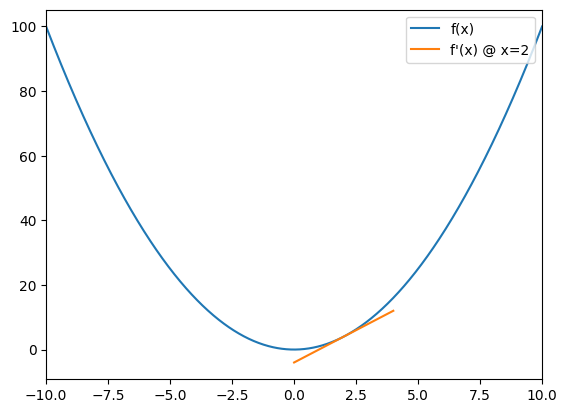

In [62]:
plot_tangent_line_at_point(lambda x: x ** 2, 2)

Looks like it! Let's zoom in to confirm:

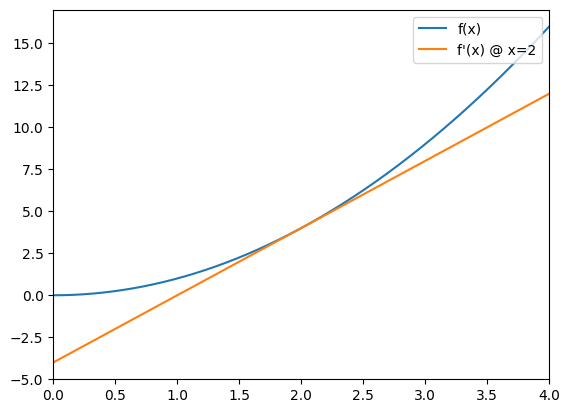

In [63]:
plot_tangent_line_at_point(lambda x: x ** 2, 2, min_x = 0, max_x = 4)

Let's also plot several tangents to the same function. Note that this will create many graphs by default. You can plot them all at once if you wish.

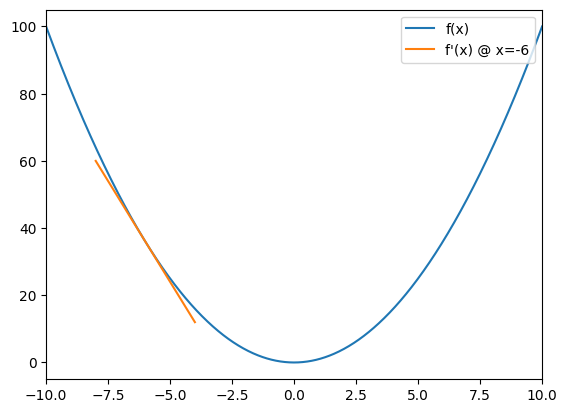

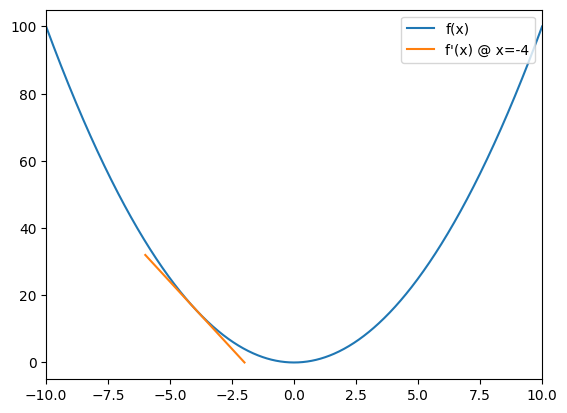

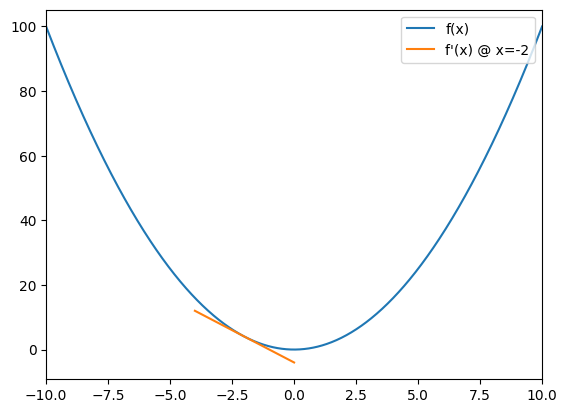

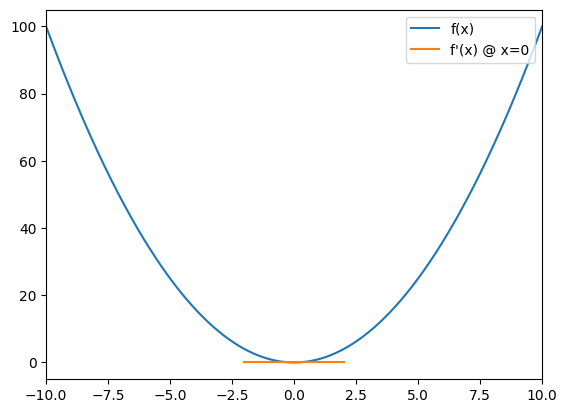

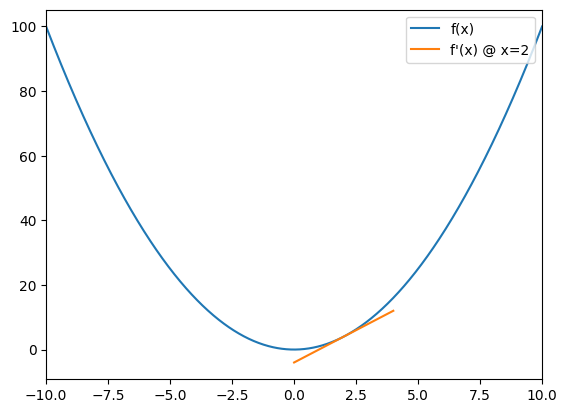

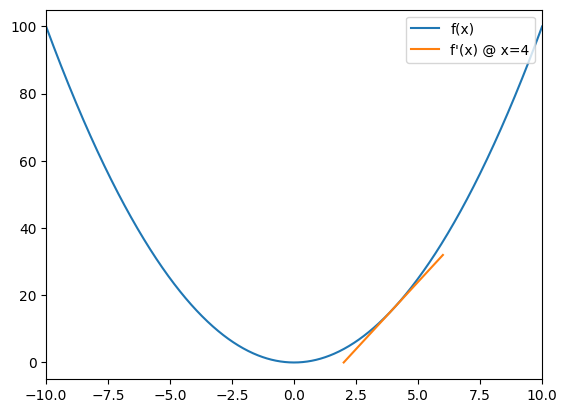

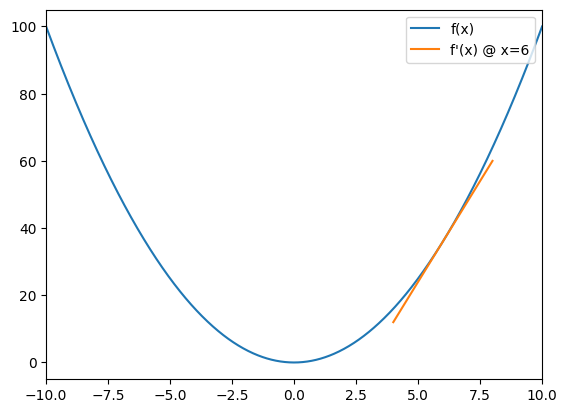

In [64]:
for random_value in np.arange(-6, 8, 2):
    plot_tangent_line_at_point(lambda x: x ** 2, random_value)

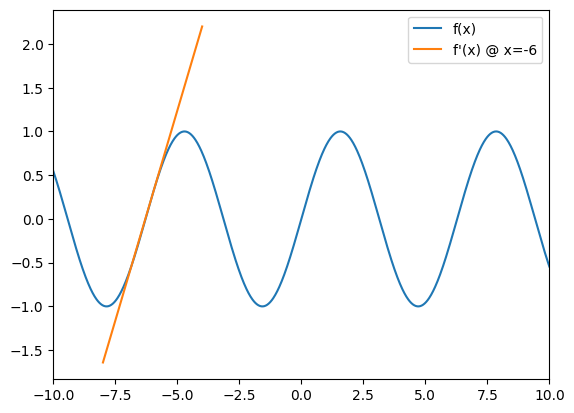

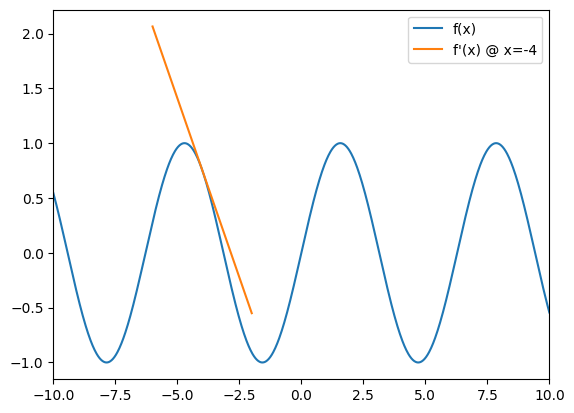

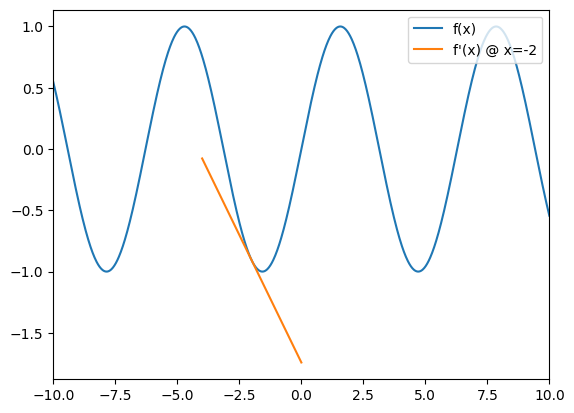

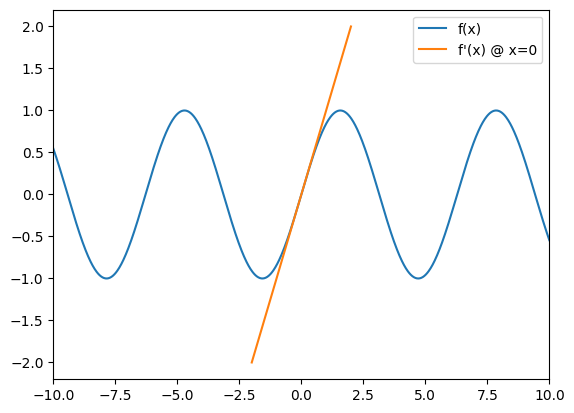

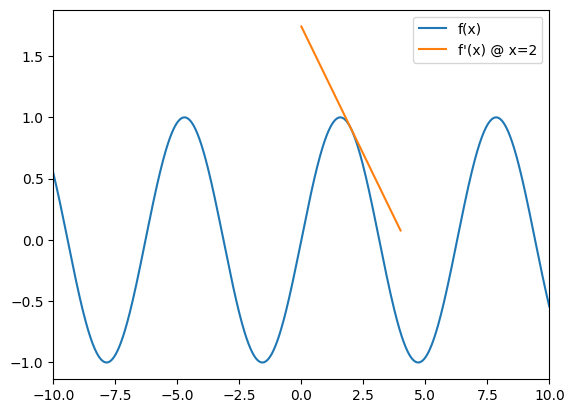

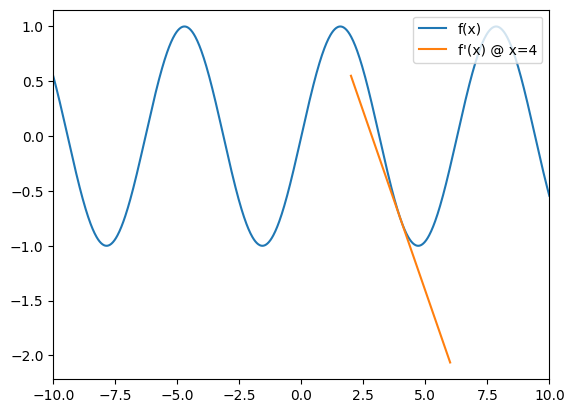

In [65]:
for random_value in np.arange(-6, 6, 2):
    plot_tangent_line_at_point(np.sin, random_value)

Now we have a visual proof that the **derivative of a function at a given point is equal to the slope** of the tangent line to the function.

In other words the derivative function represents the speed (the slope) with which the original (primitive) function changes at every point.